# Tokens Llama por PCDT (Chroma)

Conta tokens com o **vocabulário do modelo de geração** (Llama 3.2 3B), não com `nomic-embed-text`.

## Visão geral

- **Cache em memória**: reexecutar com o mesmo `MAX_DOCUMENTS` não recalcula; aumentar o limite só processa PCDTs novos.
- **Decisão de contexto**: colunas `retrieval_block_est`, `fits_full_doc_*`, comparação com `CONTEXT_WINDOW`.

**Pré-requisitos:** vectorstore em `vectorstore/chroma`, venv com `pip install -e .` em `llm/`. Para tokenizer MLX: `pip install mlx-lm huggingface_hub`.

## Índice

1. Dependências (opcional)
2. Configuração e tokenizer
3. DataFrame por PCDT (`df`)
4. Glossário das colunas
5. Relatório resumido
6. Retrieve global
7. Consultas úteis (pandas)
8. Chunks acima de 400 tokens
9. Distribuições
10. Escolher `k` (curva acumulada)
11. VRAM vs contexto (quantização)


## 1. Dependências (opcional)

Instale `mlx-lm` e `huggingface_hub` na primeira execução, se usar `TOKENIZER_BACKEND="mlx"`.


In [1]:
# Opcional — só na primeira vez (Apple Silicon + MLX)
# !uv pip install mlx-lm huggingface_hub ipywidgets

## 2. Configuração e tokenizer

Parâmetros (`MAX_DOCUMENTS`, `RETRIEVAL_K`, `CONTEXT_WINDOW`) e carregamento do tokenizador Llama.


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
LLM_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SCRIPTS = LLM_ROOT / "scripts"
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(LLM_ROOT / "src"))

from chroma_llama_token_analysis import (
    ChromaLlamaTokenAnalyzer,
    DEFAULT_CONTEXT_WINDOW,
    DEFAULT_HF_TOKENIZER_REPO,
    DEFAULT_RETRIEVAL_K,
    DEFAULT_MAX_K_CHART,
    MAX_REFERENCE_CONTEXT,
    context_report_summary,
    report_top_by_total_tokens,
    report_pcdts_fitting_full_document,
    report_pcdts_fitting_retrieval_block,
    report_pcdts_with_oversized_chunks,
    report_retrieval_block_pct_stats,
    recommend_k_for_budgets,
    plot_cumulative_top_chunks_profile,
    max_n_chunks_within_budget,
    STANDARD_CONTEXT_BUDGETS,
    build_vram_context_profile,
    vram_pivot_table,
    plot_vram_by_context_length,
    DEFAULT_QUANTIZATION_PROFILES,
    DEFAULT_LLAMA_VRAM_SPEC,
)
from pcdt_ingest.paths import vectorstore_chroma_dir

# --- Parâmetros (ajuste por célula) ---
MAX_DOCUMENTS = None          # None = todos os PCDTs; aumente incrementalmente
TOKENIZER_BACKEND = "mlx"     # "mlx" | "transformers" (sem MLX)
HF_REPO = DEFAULT_HF_TOKENIZER_REPO
RETRIEVAL_K = DEFAULT_RETRIEVAL_K   # alinhar com MEDICO_RETRIEVAL_K do backend
CONTEXT_WINDOW = 32_000  # ex.: 32_000 ou 128_000

analyzer = ChromaLlamaTokenAnalyzer(
    chroma_dir=vectorstore_chroma_dir(),
    hf_repo=HF_REPO,
    tokenizer_backend=TOKENIZER_BACKEND,
    retrieval_k=RETRIEVAL_K,
    context_window=CONTEXT_WINDOW,
)
print("Chroma:", analyzer.chroma_dir)
print("Tokenizer:", analyzer.ensure_tokenizer())
print("Cache antes:", analyzer.cache_summary())


Chroma: /Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/vectorstore/chroma


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Tokenizer: mlx-lm (unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit)
Cache antes: {'chunks_tokenized': 0, 'documents_cached': 0, 'max_documents_seen': 0, 'hf_repo': 'unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit', 'chroma_fingerprint': None}


## 3. DataFrame por PCDT (`df`)

Uma linha por `source_stem`; tokenização com cache incremental.


In [3]:
df = analyzer.compute_dataframe(max_documents=MAX_DOCUMENTS)
print("Cache depois:", analyzer.cache_summary())
print(f"PCDTs na tabela: {len(df)}")
df

Cache depois: {'chunks_tokenized': 15541, 'documents_cached': 132, 'max_documents_seen': 132, 'hf_repo': 'unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit', 'chroma_fingerprint': '/Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/vectorstore/chroma|pcdt|15541'}
PCDTs na tabela: 132


,source_stem,chunks,total_tokens,max_chunk_tokens,min_chunk_tokens,avg_chunk_tokens,p95_chunk_tokens,sum_top_6_largest,sum_top_6_smallest,retrieval_block_est,...,fits_full_doc_8k,fits_full_doc_16k,fits_full_doc_32k,fits_retrieval_k_8k,fits_retrieval_k_16k,fits_retrieval_k_32k,chars_estimate_total,sum_top_10_largest,sum_top_15_largest,sum_top_20_largest
0,pcdt_manejo_hiv_adulto-1,565,141218,590,12,249.9,495,3338,76,3668,...,False,False,False,True,True,True,116890,5458,8040,10577
1,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,463,140222,1842,12,302.9,514,6793,87,7123,...,False,False,False,True,True,True,114186,9497,12504,15233
2,20211220_portal_retinopatia_diabetica,317,113081,1854,9,356.7,803,7726,66,8056,...,False,False,False,False,True,True,77749,11316,15563,19377
3,20210429_pcdt-ist_588,379,103761,566,6,273.8,499,3184,99,3514,...,False,False,False,True,True,True,87394,5235,7769,10272
4,pcdt-da-brucelose-humana,285,98303,2081,7,344.9,562,6752,189,7082,...,False,False,False,True,True,True,77539,9200,12025,14801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,pcdt_angioedema-deficincia-c1esterase_2016,29,6342,522,15,218.7,454,2587,187,2917,...,True,True,True,True,True,True,5310,3828,5056,5899
128,pcdt_hipoparatireoidismo_29-04-2016,26,6189,484,49,238.0,465,2695,405,3025,...,True,True,True,True,True,True,5071,3894,5090,5784
129,20210820_portaria_conjunta_n13_pcdt_lam,24,5418,533,18,225.8,412,2444,255,2774,...,True,True,True,True,True,True,4622,3736,4767,5314
130,pcdt_insuficienciapancreaticaexocrina-fev2016,24,4369,481,19,182.0,408,2227,209,2557,...,True,True,True,True,True,True,3921,3184,3947,4252


## 4. Glossário das colunas

### O que é `retrieval_block_est`? (leia primeiro)

**Pergunta que responde:** *se este PCDT aparecer num turno de chat, quantos tokens Llama o **bloco de trechos PCDT** no prompt pode ocupar?*

**O que mede:** só o texto que o backend monta em `format_context_block` (trechos + cabeçalho `[n] PCDT stem=… págs. …` por chunk). **Não** é o resultado de uma busca real, nem o prompt completo.

**Como calcula (proxy pessimista):**

1. Pega os **k** maiores chunks deste PCDT no Chroma (`k` = `RETRIEVAL_K`, padrão 6).
2. Soma os tokens Llama deles → `sum_top_{k}_largest`.
3. Soma **k × 55** tokens (estimativa do cabeçalho de cada chunk).
4. **`retrieval_block_est` = passo 2 + passo 3.**

Na prática o retrieve escolhe chunks por **similaridade** à pergunta, não pelo tamanho. Usamos os k maiores como **teto conservador**.

**O que fica de fora:** system prompt, histórico, pergunta do médico, resposta do modelo, separadores `---`.

**Por PCDT vs global:** `retrieval_block_est` é **por documento**. O backend faz `similarity_search(k=RETRIEVAL_K)` na **coleção inteira** — ver **§6** (`pct_context_window`). **§7** calcula quantos maiores chunks cabem na janela inteira (`max_chunks_fit`).

| Objetivo | Coluna |
|----------|--------|
| Aumentar `k`? | `retrieval_block_pct_context` baixo |
| PCDT inteiro no prompt? | `total_tokens`, `fits_full_doc_*` |
| Chunks enormes? | `max_chunk_tokens`, §8 |
| vs janela do modelo | `retrieval_block_est`; reserve ~2–4k para prompt + histórico |

---

### Tabela — `df` (um PCDT por linha)

| Coluna | Significado |
|--------|-------------|
| `source_stem` | Identificador do PCDT no Chroma. |
| `chunks` | Quantidade de chunks desse PCDT. |
| `total_tokens` | Soma Llama de **todos** os chunks (documento inteiro). |
| `max_chunk_tokens` / `min_chunk_tokens` | Maior / menor chunk. |
| `avg_chunk_tokens` | Média por chunk. |
| `p95_chunk_tokens` | Percentil 95 (cauda grande). |
| `sum_top_{k}_largest` | Soma dos k maiores chunks; base de `retrieval_block_est`. |
| `sum_top_{k}_smallest` | Soma dos k menores (cenário otimista). |
| `retrieval_block_est` | Orçamento pessimista do bloco PCDT no prompt (ver acima). |
| `full_doc_pct_context` | `total_tokens` ÷ `CONTEXT_WINDOW` (%). |
| `retrieval_block_pct_context` | `retrieval_block_est` ÷ `CONTEXT_WINDOW` (%). |
| `fits_in_context_window` | PCDT inteiro cabe em `CONTEXT_WINDOW` (config da célula §2). |
| `fits_retrieval_in_context_window` | `retrieval_block_est` cabe em `CONTEXT_WINDOW`. |
| `fits_full_doc_*` / `fits_retrieval_k_*` | Referência fixa 8k / 16k / 32k (legado). |
| `chars_estimate_total` | Estimativa `chars ÷ 4` vs contagem Llama. |
| `sum_top_6_largest`, … | Simular outros valores de **k**. |

### Tabela — `chunks_over_400` (um chunk por linha)

| Coluna | Significado |
|--------|-------------|
| `chunk_id` | ID no Chroma. |
| `source_stem` | PCDT do chunk. |
| `llama_tokens` | Tokens Llama do texto. |
| `chars` | Caracteres (não tokens). |
| `page_start` / `page_end` | Páginas no PDF. |
| `section` | Seção/título na metadata. |
| `text_preview` | Início do texto (~160 caracteres). |


## 5. Relatório resumido

Visão rápida do escopo tokenizado. Cada subseção traz explicação em markdown e a tabela em uma célula de código (sem `print` de cabeçalhos).


### 5.1 Resumo numérico

Contagens do escopo atual (`df`). Valores dinâmicos — dependem de `MAX_DOCUMENTS` e de ter reexecutado a §3.


In [4]:
_summary = context_report_summary(
    df, context_window=CONTEXT_WINDOW, retrieval_k=RETRIEVAL_K
)
if _summary["pcdt_count"] == 0:
    print("DataFrame vazio — execute a §3 com Chroma populado.")
else:
    print(
        f"{_summary['pcdt_count']} PCDTs · {_summary['chunk_count']:,} chunks · "
        f"{_summary['grand_tokens']:,} tokens Llama"
    )
    print(f"CONTEXT_WINDOW={CONTEXT_WINDOW:,} · RETRIEVAL_K={RETRIEVAL_K}")
    if _summary.get("fits_full_doc_count") is not None:
        print(
            f"PCDTs que cabem inteiros na janela: {_summary['fits_full_doc_count']} / "
            f"{_summary['pcdt_count']}"
        )
    if _summary.get("fits_retrieval_count") is not None:
        print(
            f"PCDTs com retrieve (k maiores) na janela: "
            f"{_summary['fits_retrieval_count']} / {_summary['pcdt_count']}"
        )
    print(f"PCDTs com algum chunk > 600 tokens: {_summary['heavy_chunk_pcdt_count']}")


132 PCDTs · 15,541 chunks · 4,249,631 tokens Llama
CONTEXT_WINDOW=32,000 · RETRIEVAL_K=6
PCDTs que cabem inteiros na janela: 82 / 132
PCDTs com retrieve (k maiores) na janela: 132 / 132
PCDTs com algum chunk > 600 tokens: 52


### 5.2 Top 15 PCDTs por tamanho total

Maiores documentos indexados (soma de **todos** os chunks). Útil para ver quais protocolos dominariam o contexto se fossem injetados por inteiro.


In [5]:
report_top_by_total_tokens(df, RETRIEVAL_K, head=15)


,source_stem,chunks,total_tokens,max_chunk_tokens,avg_chunk_tokens,sum_top_6_largest,retrieval_block_est,full_doc_pct_context,retrieval_block_pct_context
0,pcdt_manejo_hiv_adulto-1,565,141218,590,249.9,3338,3668,441.31,11.46
1,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,463,140222,1842,302.9,6793,7123,438.19,22.26
2,20211220_portal_retinopatia_diabetica,317,113081,1854,356.7,7726,8056,353.38,25.18
3,20210429_pcdt-ist_588,379,103761,566,273.8,3184,3514,324.25,10.98
4,pcdt-da-brucelose-humana,285,98303,2081,344.9,6752,7082,307.20,22.13
5,20201113_pcdt_para_ptv_hiv_final,323,86523,568,267.9,3227,3557,270.38,11.12
6,20220323_portal-portaria-conjunta-no-5-pcdt_es...,228,79681,1591,349.5,5961,6291,249.00,19.66
7,20230524_Relatrio_PCDTHepatiteB,252,74242,619,294.6,3286,3616,232.01,11.30
8,pcdt-da-artrite-reumatoide,242,74140,1167,306.4,3974,4304,231.69,13.45
9,pcdt_doenca_de_chagas,265,73231,637,276.3,3501,3831,228.85,11.97


### 5.3 PCDTs que cabem na janela (documento inteiro)

Linhas com `fits_in_context_window == True` — `total_tokens` ≤ `CONTEXT_WINDOW` usado ao gerar o `df` (§2–§3).


In [6]:
report_pcdts_fitting_full_document(df, RETRIEVAL_K)


,source_stem,chunks,total_tokens,max_chunk_tokens,avg_chunk_tokens,sum_top_6_largest,retrieval_block_est,full_doc_pct_context,retrieval_block_pct_context
50,portaria_conjunta_14_pcdt_doenca_de_crohn_28_1...,99,31738,1035,320.6,3972,4302,99.18,13.44
51,pcdt-anemia-hemolitica-autoimune,103,30800,622,299.0,3424,3754,96.25,11.73
52,pcdt-munopolissacaridose-tipo-i,103,30616,552,297.2,3235,3565,95.67,11.14
53,20221216_pcdt-dmri,107,29896,554,279.4,3075,3405,93.42,10.64
54,protocolo-clinico-e-diretrizes-terapeuticas-pa...,107,29868,583,279.1,3341,3671,93.34,11.47
...,...,...,...,...,...,...,...,...,...
127,pcdt_angioedema-deficincia-c1esterase_2016,29,6342,522,218.7,2587,2917,19.82,9.12
128,pcdt_hipoparatireoidismo_29-04-2016,26,6189,484,238.0,2695,3025,19.34,9.45
129,20210820_portaria_conjunta_n13_pcdt_lam,24,5418,533,225.8,2444,2774,16.93,8.67
130,pcdt_insuficienciapancreaticaexocrina-fev2016,24,4369,481,182.0,2227,2557,13.65,7.99


### 5.4 PCDTs com bloco retrieve na janela (k por documento)

Proxy **por PCDT**: soma dos `RETRIEVAL_K` maiores chunks + cabeçalhos (`retrieval_block_est`). Compare com a §6 (global) e §7 (capacidade máxima).


In [7]:
report_pcdts_fitting_retrieval_block(df, RETRIEVAL_K)


,source_stem,chunks,total_tokens,max_chunk_tokens,avg_chunk_tokens,sum_top_6_largest,retrieval_block_est,full_doc_pct_context,retrieval_block_pct_context
0,pcdt_manejo_hiv_adulto-1,565,141218,590,249.9,3338,3668,441.31,11.46
1,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,463,140222,1842,302.9,6793,7123,438.19,22.26
2,20211220_portal_retinopatia_diabetica,317,113081,1854,356.7,7726,8056,353.38,25.18
3,20210429_pcdt-ist_588,379,103761,566,273.8,3184,3514,324.25,10.98
4,pcdt-da-brucelose-humana,285,98303,2081,344.9,6752,7082,307.20,22.13
...,...,...,...,...,...,...,...,...,...
127,pcdt_angioedema-deficincia-c1esterase_2016,29,6342,522,218.7,2587,2917,19.82,9.12
128,pcdt_hipoparatireoidismo_29-04-2016,26,6189,484,238.0,2695,3025,19.34,9.45
129,20210820_portaria_conjunta_n13_pcdt_lam,24,5418,533,225.8,2444,2774,16.93,8.67
130,pcdt_insuficienciapancreaticaexocrina-fev2016,24,4369,481,182.0,2227,2557,13.65,7.99


### 5.5 PCDTs com chunks individuais muito grandes

Vários chunks com mais de **600** tokens Llama — candidatos a revisar na fragmentação (alvo em `llm/config.py`: 400).


In [8]:
oversized_chunks =report_pcdts_with_oversized_chunks(df, min_max_chunk_tokens=600)

display(oversized_chunks)

print(f"PCDTs com chunks > 600 tokens: {len(oversized_chunks)}")


,source_stem,chunks,max_chunk_tokens,avg_chunk_tokens
38,20220926_pcdt_osteogenese_imperfeita,130,2224,289.5
4,pcdt-da-brucelose-humana,285,2081,344.9
65,pcdt-vasculite-associada-aos-anticorpos-anti-c...,91,1920,281.8
2,20211220_portal_retinopatia_diabetica,317,1854,356.7
1,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,463,1842,302.9
6,20220323_portal-portaria-conjunta-no-5-pcdt_es...,228,1591,349.5
58,pcdt-porfirias,96,1492,297.4
68,pcdt_sindromenefroticaprimaria_criancasadolesc...,86,1460,281.4
41,portaria-no-22-pcdt-da-osteoporose,119,1441,293.9
60,20221109_pcdt_sindrome_falencias_medulares,92,1434,302.0


PCDTs com chunks > 600 tokens: 52


### 5.6 Distribuição de `retrieval_block_pct_context`

Percentual da janela consumido pelo bloco retrieve **pessimista** (k maiores chunks por PCDT). Mediana e cauda alta indicam protocolos “pesados” no retrieve.


In [9]:
report_retrieval_block_pct_stats(df)


,retrieval_block_pct_context
count,132.000000
mean,11.470076
std,2.961661
min,5.120000
50%,10.825000
75%,12.092500
90%,13.957000
95%,16.859500
max,25.180000


**Próximo:** §6 — `k` maiores chunks **em toda a coleção**; §7 — quantos maiores chunks cabem empilhados na janela.


## 6. Retrieve global (como o backend)

Os **k** maiores chunks de **todo o escopo** + cabeçalhos; compare `pct_context_window` com `CONTEXT_WINDOW`.


In [10]:
global_est = analyzer.estimate_global_retrieval_block(
    max_documents=MAX_DOCUMENTS,
    retrieval_k=RETRIEVAL_K,
    context_window=CONTEXT_WINDOW,
)

print(
    f"Escopo: {global_est['scope_pcdts']} PCDTs, {global_est['scope_chunks']:,} chunks "
    f"(MAX_DOCUMENTS={MAX_DOCUMENTS})"
)
print(f"k = {global_est['retrieval_k']} maiores chunks **em toda a coleção (escopo)**:\n")
print(f"  corpo (texto):     {global_est['sum_body_tokens']:>8,} tokens")
print(f"  cabeçalhos (k×55): {global_est['sum_header_tokens']:>8,} tokens")
print(f"  total estimado:    {global_est['global_retrieval_block_est']:>8,} tokens")
print(
    f"\n  ≈ {global_est['pct_context_window']}% de CONTEXT_WINDOW ({CONTEXT_WINDOW:,})"
)
print(
    f"  folga restante (só bloco PCDT): "
    f"{CONTEXT_WINDOW - global_est['global_retrieval_block_est']:,} tokens"
)

global_est["top_chunks"]

Escopo: 132 PCDTs, 15,541 chunks (MAX_DOCUMENTS=None)
k = 6 maiores chunks **em toda a coleção (escopo)**:

  corpo (texto):       11,539 tokens
  cabeçalhos (k×55):      330 tokens
  total estimado:      11,869 tokens

  ≈ 37.09% de CONTEXT_WINDOW (32,000)
  folga restante (só bloco PCDT): 20,131 tokens


,chunk_id,source_stem,llama_tokens,chars,page_start,page_end,section,text_preview
0,20220926_pcdt_osteogenese_imperfeita:47,20220926_pcdt_osteogenese_imperfeita,2224,5668,21,24,**Métodos e resultados da busca**,Embase | #1 (‘osteogenesis imperfecta’/exp OR ...
1,pcdt-da-brucelose-humana:162,pcdt-da-brucelose-humana,2081,4654,121,123,**Análise e Apresentação dos Resultados**,melitensis_ (11) | Ambos: 21.42±14.52 **Agalar...
2,pcdt-vasculite-associada-aos-anticorpos-anti-c...,pcdt-vasculite-associada-aos-anticorpos-anti-c...,1920,5313,38,42,**ANCA associada?**,- Métodos e resultados da busca decortancyl OR...
3,20211220_portal_retinopatia_diabetica:193,20211220_portal_retinopatia_diabetica,1854,3350,129,132,**1.1 Grupo intervenção: Inibidores do fator d...,** **2016126** (Revisão Sistemática com metaan...
4,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,1842,3782,298,300,**Tabela K1.** Resultados de segurança dos est...,"**Halern 2002** **Porter 2004** | **Fanghänel,..."
5,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,1618,3091,73,77,**C. Descrição dos estudos e resultados**,"**Autor, ano** **Intervenção** **Controle** | ..."


## 7. Consultas úteis (pandas)

Filtros para decidir se pode aumentar `k`, usar chunks maiores ou injetar o PCDT inteiro.


### 8.1 PCDTs que cabem na janela (`CONTEXT_WINDOW`)

Documentos inteiros cujo `total_tokens` ≤ `CONTEXT_WINDOW` (mesmo valor da célula de configuração). Se a §7 já rodou, usa `CONTEXT_WINDOW - PROMPT_RESERVE` como orçamento para o texto PCDT.


In [11]:
DOC_BUDGET = CONTEXT_WINDOW - (PROMPT_RESERVE if "PROMPT_RESERVE" in globals() else 0)

print(f"Contexto de referência: {CONTEXT_WINDOW:,} tokens")

df.query("total_tokens <= @DOC_BUDGET").sort_values("total_tokens", ascending=False)[
    ["source_stem", "chunks", "total_tokens", "full_doc_pct_context"]
]

Contexto de referência: 32,000 tokens


,source_stem,chunks,total_tokens,full_doc_pct_context
50,portaria_conjunta_14_pcdt_doenca_de_crohn_28_1...,99,31738,99.18
51,pcdt-anemia-hemolitica-autoimune,103,30800,96.25
52,pcdt-munopolissacaridose-tipo-i,103,30616,95.67
53,20221216_pcdt-dmri,107,29896,93.42
54,protocolo-clinico-e-diretrizes-terapeuticas-pa...,107,29868,93.34
...,...,...,...,...
127,pcdt_angioedema-deficincia-c1esterase_2016,29,6342,19.82
128,pcdt_hipoparatireoidismo_29-04-2016,26,6189,19.34
129,20210820_portaria_conjunta_n13_pcdt_lam,24,5418,16.93
130,pcdt_insuficienciapancreaticaexocrina-fev2016,24,4369,13.65


### 7.2 Retrieve com folga na janela

Bloco retrieve estimado usa menos de 5% de `CONTEXT_WINDOW`.


In [12]:
col_k = f"sum_top_{RETRIEVAL_K}_largest"

print(f"Contexto de referência: {CONTEXT_WINDOW:,} tokens")
df.assign(block_pct=100 * (df[col_k] + RETRIEVAL_K * 55) / CONTEXT_WINDOW).query("block_pct < 5").sort_values(col_k)[[
    "source_stem", "chunks", col_k, "retrieval_block_est", "retrieval_block_pct_context"
]]

Contexto de referência: 32,000 tokens


,source_stem,chunks,sum_top_6_largest,retrieval_block_est,retrieval_block_pct_context


### 7.3 Candidatos a PCDT inteiro no prompt

Menos de 25% da janela se todos os chunks fossem injetados.


In [13]:
print(f"Contexto de referência: {CONTEXT_WINDOW:,} tokens")

df.assign(
    headroom_tokens=CONTEXT_WINDOW - df["total_tokens"],
    llama_vs_chars_ratio=df["total_tokens"] / df["chars_estimate_total"].clip(lower=1),
).query("full_doc_pct_context < 25").sort_values("total_tokens", ascending=False)[[
    "source_stem", "total_tokens", "headroom_tokens", "chunks", "max_chunk_tokens", "llama_vs_chars_ratio"
]]

Contexto de referência: 32,000 tokens


,source_stem,total_tokens,headroom_tokens,chunks,max_chunk_tokens,llama_vs_chars_ratio
121,pcdt-imunodeficienciaprimaria,7890,24110,31,489,1.183618
122,20201022_portaria_conjunta_pcdt_sgb-1,7722,24278,39,455,1.173021
123,ddt_linfomadifusob_26092014,7676,24324,30,499,1.234282
124,20210426_portaria_conjunta_pcdt_hipotireoidism...,7238,24762,31,526,1.208953
125,portaria-conjunta-pcdt-colangite-biliar-saes,6538,25462,29,487,1.190676
126,pcdt-hiperplasia-adrenal-congenita-livro-2010,6372,25628,50,498,1.216263
127,pcdt_angioedema-deficincia-c1esterase_2016,6342,25658,29,522,1.194350
128,pcdt_hipoparatireoidismo_29-04-2016,6189,25811,26,484,1.220469
129,20210820_portaria_conjunta_n13_pcdt_lam,5418,26582,24,533,1.172220
130,pcdt_insuficienciapancreaticaexocrina-fev2016,4369,27631,24,481,1.114257


### 7.4 PCDTs com chunks muito grandes

Maior chunk passa de 500 tokens.


In [14]:
df.query("max_chunk_tokens > 500").sort_values("max_chunk_tokens", ascending=False)

,source_stem,chunks,total_tokens,max_chunk_tokens,min_chunk_tokens,avg_chunk_tokens,p95_chunk_tokens,sum_top_6_largest,sum_top_6_smallest,retrieval_block_est,...,fits_full_doc_8k,fits_full_doc_16k,fits_full_doc_32k,fits_retrieval_k_8k,fits_retrieval_k_16k,fits_retrieval_k_32k,chars_estimate_total,sum_top_10_largest,sum_top_15_largest,sum_top_20_largest
38,20220926_pcdt_osteogenese_imperfeita,130,37635,2224,6,289.5,512,5085,128,5415,...,False,False,False,True,True,True,30577,7102,9514,11795
4,pcdt-da-brucelose-humana,285,98303,2081,7,344.9,562,6752,189,7082,...,False,False,False,True,True,True,77539,9200,12025,14801
65,pcdt-vasculite-associada-aos-anticorpos-anti-c...,91,25647,1920,29,281.8,497,4507,211,4837,...,False,False,True,True,True,True,21560,6435,8692,10779
2,20211220_portal_retinopatia_diabetica,317,113081,1854,9,356.7,803,7726,66,8056,...,False,False,False,False,True,True,77749,11316,15563,19377
1,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,463,140222,1842,12,302.9,514,6793,87,7123,...,False,False,False,True,True,True,114186,9497,12504,15233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28,20220419_portal-portaria_conjunta_7_comportame...,155,43498,509,6,280.6,471,2933,140,3263,...,False,False,False,True,True,True,37816,4820,7138,9424
108,pcdt_anemia_doencarenalcronica,41,12523,509,23,305.4,467,2864,276,3194,...,False,True,True,True,True,True,10630,4616,6662,8584
131,pcdt-acidentes-ofidicos,19,4073,508,47,214.4,376,2072,649,2402,...,True,True,True,True,True,True,3394,2940,3713,4073
114,20210701_portaria_conjunta_pcdt_insuficencia_a...,40,10433,506,23,260.8,449,2691,363,3021,...,False,True,True,True,True,True,8801,4172,5876,7314


## 8. Chunks acima do alvo de chunking

Chunk a chunk com mais de 400 tokens Llama.


In [15]:
# Alinhado a CHUNK_TOKENS em llm/config.py
CHUNK_LLAMA_THRESHOLD = 400

chunks_over_400 = analyzer.compute_chunks_dataframe(
    max_documents=MAX_DOCUMENTS,
    min_llama_tokens=CHUNK_LLAMA_THRESHOLD,
)
print(
    f"{len(chunks_over_400)} chunks com mais de {CHUNK_LLAMA_THRESHOLD} tokens Llama "
    f"(escopo: MAX_DOCUMENTS={MAX_DOCUMENTS})"
)
chunks_over_400

3955 chunks com mais de 400 tokens Llama (escopo: MAX_DOCUMENTS=None)


,chunk_id,source_stem,llama_tokens,chars,page_start,page_end,section,text_preview
0,20220926_pcdt_osteogenese_imperfeita:47,20220926_pcdt_osteogenese_imperfeita,2224,5668,21,24,**Métodos e resultados da busca**,Embase | #1 (‘osteogenesis imperfecta’/exp OR ...
1,pcdt-da-brucelose-humana:162,pcdt-da-brucelose-humana,2081,4654,121,123,**Análise e Apresentação dos Resultados**,melitensis_ (11) | Ambos: 21.42±14.52 **Agalar...
2,pcdt-vasculite-associada-aos-anticorpos-anti-c...,pcdt-vasculite-associada-aos-anticorpos-anti-c...,1920,5313,38,42,**ANCA associada?**,- Métodos e resultados da busca decortancyl OR...
3,20211220_portal_retinopatia_diabetica:193,20211220_portal_retinopatia_diabetica,1854,3350,129,132,**1.1 Grupo intervenção: Inibidores do fator d...,** **2016126** (Revisão Sistemática com metaan...
4,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,20201113_pcdt_sobrepeso_e_obesidade_em_adultos...,1842,3782,298,300,**Tabela K1.** Resultados de segurança dos est...,"**Halern 2002** **Porter 2004** | **Fanghänel,..."
...,...,...,...,...,...,...,...,...
3950,pcdt-doenca-de-parkinson:125,pcdt-doenca-de-parkinson,401,1311,74,74,Referências,"1. Goetz CG, Tilley BC, Shaftman SR, Stebbins ..."
3951,pcdt-diabete-melito-tipo-2:150,pcdt-diabete-melito-tipo-2,401,1445,63,64,MATERIAL SUPLEMENTAR A – ORIENTAÇÃO EM RELAÇÃO...,A via de administração ambulatorial das insuli...
3952,pcdt-diabete-melito-tipo-2:139,pcdt-diabete-melito-tipo-2,401,1270,56,56,"REGULAÇÃO, CONTROLE E AVALIAÇÃO PELO GESTOR",Diabetes Care [Internet]. 2021 Dec 16;45(Suppl...
3953,pcdt-diabete-melito-tipo-2:37,pcdt-diabete-melito-tipo-2,401,1490,15,15,8.2.1. Alimentação e nutrição,"A abordagem deve ser individualizada, conforme..."


## 9. Distribuições

Histogramas de `total_tokens` e `retrieval_block_est`.


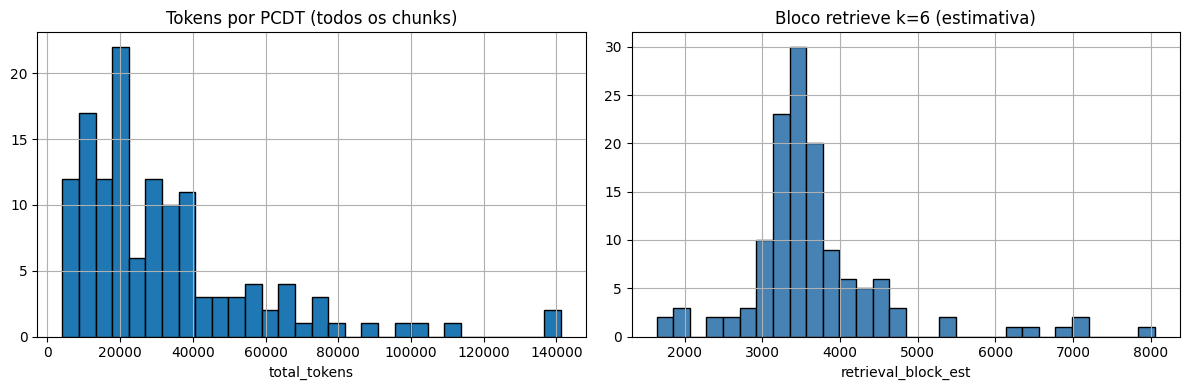

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["total_tokens"].hist(ax=axes[0], bins=30, edgecolor="black")
axes[0].set_title("Tokens por PCDT (todos os chunks)")
axes[0].set_xlabel("total_tokens")
df["retrieval_block_est"].hist(ax=axes[1], bins=30, edgecolor="black", color="steelblue")
axes[1].set_title(f"Bloco retrieve k={RETRIEVAL_K} (estimativa)")
axes[1].set_xlabel("retrieval_block_est")
plt.tight_layout()
plt.show()

## 10. Escolher `k` pela curva acumulada

**Como ler o gráfico (célula seguinte):**

| Eixo | O que é |
|------|---------|
| **Horizontal (→)** | `k` = quantos trechos entram no prompt (os **k maiores** do índice, não por similaridade). |
| **Vertical (↑)** | Tokens Llama do bloco PCDT (texto dos trechos + cabeçalho `[n] PCDT…` por trecho). |

| Elemento | Significado |
|----------|-------------|
| **Curva azul** | “Se eu retornar **k** trechos, o prompt terá **tantos** tokens.” Sobe da esquerda para a direita. |
| **Linhas horizontais cinza (2k … 256k)** | Tetos de referência até **256k** (teto do gráfico). Abaixo da linha = ainda cabe. Marcador `k≤N` = maior k abaixo dessa linha. |
| **Linha laranja** | `DOC_BUDGET` — espaço para PCDT após reservar prompt/histórico (`PROMPT_RESERVE`). |
| **Linha vermelha** | `CONTEXT_WINDOW` — teto total do modelo. |
| **Área verde clara** | Zona “ainda cabe” até `DOC_BUDGET`. |
| **Ponto vermelho** | Seu `RETRIEVAL_K` atual na curva. |

| **Limite horizontal** | `MAX_K_CHART` (padrão 2000) na célula do gráfico — só os primeiros k pontos aparecem; a tabela usa o índice completo. |

A tabela na célula anterior lista o **maior k** por orçamento. Use para calibrar `RETRIEVAL_K`.


In [17]:
DOC_BUDGET = CONTEXT_WINDOW - (PROMPT_RESERVE if "PROMPT_RESERVE" in globals() else 0)

cum_profile = analyzer.build_cumulative_top_chunks_profile(
    max_documents=MAX_DOCUMENTS
)

k_table = recommend_k_for_budgets(
    cum_profile,
    STANDARD_CONTEXT_BUDGETS,
    context_window=CONTEXT_WINDOW,
    doc_budget=DOC_BUDGET,
)
k_table


,budget_label,budget_tokens,max_k,tokens_at_k
0,256,256,0,0
1,512,512,0,0
2,1k,1024,0,0
3,2k,2048,0,0
4,4k,4096,1,2279
5,8k,8192,3,6390
6,16k,16384,8,15062
7,32k,32768,20,31826
8,65k,65536,52,65419
9,131k,131072,137,131002


Maior k no DOC_BUDGET (32,000 tokens): 20 (RETRIEVAL_K atual: 6)
  → Ainda há folga para até 20 chunks no orçamento PCDT.
  → Gráfico: eixo k limitado a 130 (índice tem 15,541 pontos).


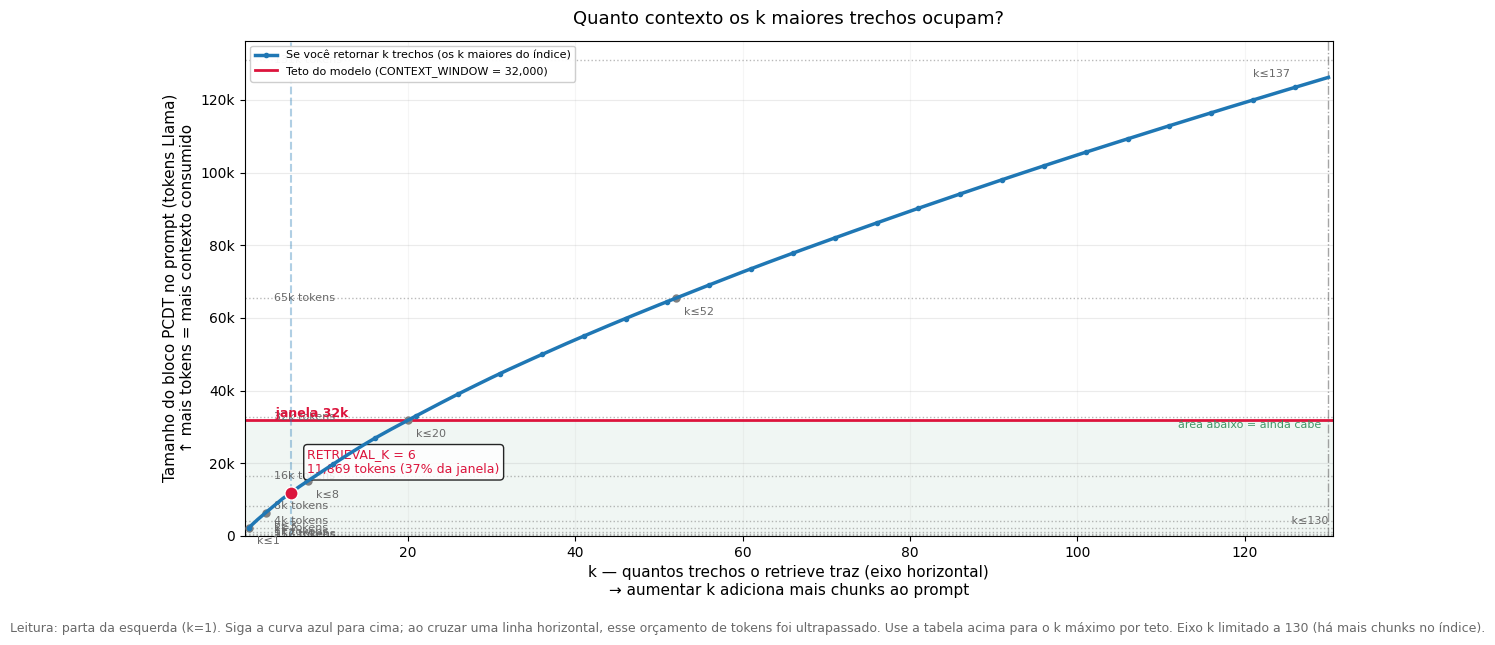

In [18]:
# Requer §2 (CONTEXT_WINDOW) e célula anterior (cum_profile)
DOC_BUDGET = CONTEXT_WINDOW - (PROMPT_RESERVE if "PROMPT_RESERVE" in globals() else 0)

# Limite do eixo k no gráfico (None = todos os chunks do escopo)
MAX_K_CHART = 130  # ou DEFAULT_MAX_K_CHART, ou None

suggested_k = max_n_chunks_within_budget(cum_profile, DOC_BUDGET)
print(
    f"Maior k no DOC_BUDGET ({DOC_BUDGET:,} tokens): {suggested_k} "
    f"(RETRIEVAL_K atual: {RETRIEVAL_K})"
)
if RETRIEVAL_K != suggested_k:
    diff = RETRIEVAL_K - suggested_k
    if diff > 0:
        print(f"  → RETRIEVAL_K está {diff} acima do teto (maior chunks).")
    else:
        print(f"  → Ainda há folga para até {suggested_k} chunks no orçamento PCDT.")
if MAX_K_CHART is not None and len(cum_profile) > MAX_K_CHART:
    print(f"  → Gráfico: eixo k limitado a {MAX_K_CHART:,} (índice tem {len(cum_profile):,} pontos).")

plot_cumulative_top_chunks_profile(
    cum_profile,
    context_window=CONTEXT_WINDOW,
    doc_budget=DOC_BUDGET,
    highlight_k=RETRIEVAL_K,
    max_k=MAX_K_CHART,
)
plt.show()



## 11. VRAM vs tamanho do contexto (por quantização)

Estimativa para **Llama 3.2 3B** em inferência (batch=1):

- **Pesos** conforme quantização (Q4_K_M ≈ Ollama 4-bit, Q8, FP16 CUDA, …).
- **KV cache** em **fp16** (cresce com o contexto).
- **Overhead** fixo (~0,75 GiB) para ativações/CUDA.

Não mede VRAM do embedder (`nomic-embed-text`). Valores reais variam ±10–20%.


In [ ]:
# Comprimentos de contexto para a tabela (referências + passo maior)
VRAM_CONTEXT_LENGTHS = []
current = min(STANDARD_CONTEXT_BUDGETS) if STANDARD_CONTEXT_BUDGETS else 256
# Garante que padrões "standard" também estejam incluídos
std_set = set(STANDARD_CONTEXT_BUDGETS)
while current < MAX_REFERENCE_CONTEXT:
    VRAM_CONTEXT_LENGTHS.append(current)
    current *= 2
VRAM_CONTEXT_LENGTHS.append(MAX_REFERENCE_CONTEXT)
# Inclui também os budgets "standard" fora do padrão dobrado
VRAM_CONTEXT_LENGTHS = sorted(set(VRAM_CONTEXT_LENGTHS).union(std_set))

vram_df = build_vram_context_profile(VRAM_CONTEXT_LENGTHS)

print("=== VRAM total (GiB) — pivot ===")
vram_pivot_table(vram_df)


=== VRAM total (GiB) — pivot ===


quant_label,BF16,FP16 (CUDA comum),FP32 (referência),"Q4_K_M (4-bit, Ollama padrão)",Q8_0 (8-bit)
context_tokens,,,,,
256,6.76,6.76,12.74,2.51,3.77
512,6.78,6.78,12.76,2.54,3.79
1024,6.84,6.84,12.82,2.59,3.85
2048,6.95,6.95,12.93,2.70,3.96
4096,7.17,7.17,13.15,2.92,4.18
8192,7.60,7.60,13.58,3.36,4.61
16384,8.48,8.48,14.46,4.23,5.49
32768,10.23,10.23,16.21,5.98,7.24
65536,13.73,13.73,19.71,9.48,10.74


VRAM na janela configurada (32,000 tokens):


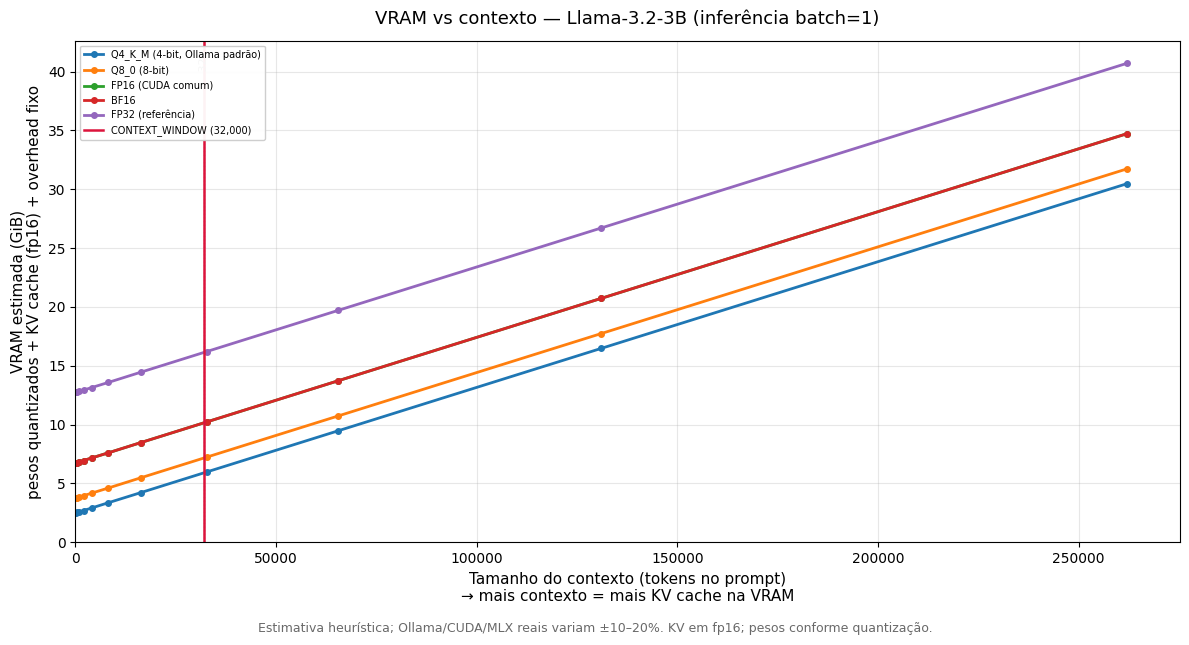

In [22]:
DOC_BUDGET_VRAM = CONTEXT_WINDOW - (PROMPT_RESERVE if "PROMPT_RESERVE" in globals() else 0)

vram_at_config = vram_df[vram_df["context_tokens"] == CONTEXT_WINDOW].sort_values(
    "total_vram_gb"
)
print(f"VRAM na janela configurada ({CONTEXT_WINDOW:,} tokens):")
vram_at_config[["quant_label", "weight_vram_gb", "kv_cache_vram_gb", "total_vram_gb"]]

plot_vram_by_context_length(
    vram_df,
    context_window=CONTEXT_WINDOW,
    doc_budget=DOC_BUDGET_VRAM,
    max_context_plot=MAX_REFERENCE_CONTEXT,
)
plt.show()
